In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

MASS = {
    "pi": 0.13957,
    "mu": 0.10566,
    "e": 0.000511,
    "p": 0.93827,
    "K": 0.49367,
    "rho": 0.77526,
    "rho_width": 0.1491,
    "Jpsi": 3.0969,
    "Psip": 3.6861,
    "Phi": 1.01946,
    "Pc": 4.360,
}

SPECIES_TO_PDG = {"e-": 11, "e+": -11, "mu-": 13, "mu+": -13, "K+": 321, "K-": -321, "p": 2212, "pbar": -2212}
PDG_TO_SPECIES = {v: k for k, v in SPECIES_TO_PDG.items()}
CHARGE_CONJ_MASS_KEY = {
    "e-": "e", "e+": "e",
    "mu-": "mu", "mu+": "mu",
    "K+": "K", "K-": "K",
    "p": "p", "pbar": "p",
}

PROCESS_CONFIG = {
    "Jpsi→mumu": {"parent_mass": MASS["Jpsi"], "daughters": ["mu+", "mu-"]},
    "Jpsi→ee":   {"parent_mass": MASS["Jpsi"], "daughters": ["e+", "e-"]},
    "Jpsi→pp":   {"parent_mass": MASS["Jpsi"], "daughters": ["p", "pbar"]},
    "Psip→mumu": {"parent_mass": MASS["Psip"], "daughters": ["mu+", "mu-"]},
    "Psip→ee":   {"parent_mass": MASS["Psip"], "daughters": ["e+", "e-"]},
    "Psip→pp":   {"parent_mass": MASS["Psip"], "daughters": ["p", "pbar"]},
    "Phi→KK":    {"parent_mass": MASS["Phi"],  "daughters": ["K+", "K-"]},
    "X→pp":      {"parent_mass": 3.0*MASS["p"], "daughters": ["p", "pbar"]},
    "γγ→mumu":   {"continuum": True, "mass_range": (2*MASS["mu"], 4.0), "daughters": ["mu+", "mu-"]},
    "γγ→ee":     {"continuum": True, "mass_range": (2*MASS["e"], 4.0),  "daughters": ["e+", "e-"]},
    "γγ→pp":     {"continuum": True, "mass_range": (2*MASS["p"], 5.0),  "daughters": ["p", "pbar"]},
    "Pc→p+mumu": {"parent_mass": MASS["Pc"], "daughters": ["p", "mu+", "mu-"]},
}

HYPOTHESIS_MASSES = {"e": MASS["e"], "mu": MASS["mu"], "K": MASS["K"], "p": MASS["p"]}

In [2]:
def eta_from_p(px, py, pz):
    p = np.sqrt(px*px + py*py + pz*pz)
    return 0.5*np.log((p + pz + 1e-12)/(p - pz + 1e-12))

def rapidity(E, pz):
    return 0.5*np.log((E + pz + 1e-12)/(E - pz + 1e-12))

def daughter_mass(species: str) -> float:
    return MASS[CHARGE_CONJ_MASS_KEY[species]]

def bethe_bloch(beta_gamma):
    """Simple Bethe-Bloch-like toy parametrisation."""
    beta_gamma = np.asarray(beta_gamma, dtype=float)
    beta_gamma = np.clip(beta_gamma, 1e-4, None)
    K, B, C, D = 15.0, 2.0, 1.5, 12.0
    return K/(beta_gamma**B) + C*np.log(beta_gamma) + D

def two_body_momentum(M, m1, m2):
    M = np.asarray(M, dtype=float)
    arg = (M**2 - (m1 + m2)**2) * (M**2 - (m1 - m2)**2)
    return np.sqrt(np.maximum(arg, 0.0))/(2*M)

def random_unit_vectors(n):
    costh = rng.uniform(-1.0, 1.0, n)
    sinth = np.sqrt(1.0 - costh*costh)
    phi = rng.uniform(0.0, 2.0*np.pi, n)
    return sinth*np.cos(phi), sinth*np.sin(phi), costh

def lorentz_boost(px, py, pz, E, bx, by, bz):
    """Boost four-vectors by velocity beta=(bx,by,bz). Vectorized."""
    b2 = bx*bx + by*by + bz*bz
    b2 = np.asarray(b2)
    gamma = 1.0 / np.sqrt(np.maximum(1.0 - b2, 1e-12))
    bp = bx*px + by*py + bz*pz
    gamma2 = np.where(b2 > 0, (gamma - 1.0) / b2, 0.0)
    
    pxp = px + gamma2*bp*bx + gamma*bx*E
    pyp = py + gamma2*bp*by + gamma*by*E  # ✅ FIXED: changed bx -> by
    pzp = pz + gamma2*bp*bz + gamma*bz*E
    Ep = gamma*(E + bp)
    return pxp, pyp, pzp, Ep

In [3]:
def generate_two_body_process(n, label, parent_mass, daughters):
    m1, m2 = [daughter_mass(x) for x in daughters]
    M = np.full(n, parent_mass, dtype=float)
    pstar = two_body_momentum(M, m1, m2)
    ux, uy, uz = random_unit_vectors(n)
    return pd.DataFrame({
        "process": label, "n_tracks": 2, "parent_mass": M,
        "px1": pstar*ux,  "py1": pstar*uy,  "pz1": pstar*uz,  "species1": daughters[0],
        "px2": -pstar*ux, "py2": -pstar*uy, "pz2": -pstar*uz, "species2": daughters[1],
        "px3": np.nan,    "py3": np.nan,    "pz3": np.nan,    "species3": None,
    })

def generate_gamma_gamma_process(n, label, mass_range, daughters):
    m1, m2 = [daughter_mass(x) for x in daughters]
    lo = max(mass_range[0], m1 + m2 + 1e-6)
    hi = mass_range[1]
    M = rng.uniform(lo, hi, n)
    pstar = two_body_momentum(M, m1, m2)
    ux, uy, uz = random_unit_vectors(n)
    return pd.DataFrame({
        "process": label, "n_tracks": 2, "parent_mass": M,
        "px1": pstar*ux,  "py1": pstar*uy,  "pz1": pstar*uz,  "species1": daughters[0],
        "px2": -pstar*ux, "py2": -pstar*uy, "pz2": -pstar*uz, "species2": daughters[1],
        "px3": np.nan,    "py3": np.nan,    "pz3": np.nan,    "species3": None,
    })

def generate_pc_to_p_mumu(n, label="Pc→p+mumu"):
    """Toy sequential 3-body decay: Pc -> p + X, X -> mu+ mu- (Vectorized)."""
    M = MASS["Pc"]
    mp, mmu = MASS["p"], MASS["mu"]
    mX = rng.uniform(2*mmu + 1e-6, M - mp - 1e-6, n)
    p_p = two_body_momentum(M, mp, mX)
    ux, uy, uz = random_unit_vectors(n)
    pxp, pyp, pzp = p_p*ux, p_p*uy, p_p*uz
    pxX, pyX, pzX = -pxp, -pyp, -pzp
    EX = np.sqrt(p_p*p_p + mX*mX)

    # X rest-frame muons
    p_mu = two_body_momentum(mX, mmu, mmu)
    vx, vy, vz = random_unit_vectors(n)
    px1, py1, pz1 = p_mu*vx, p_mu*vy, p_mu*vz
    E_mu = np.sqrt(p_mu*p_mu + mmu*mmu)

    # Boost muons from X rest frame to Pc rest frame
    bx, by, bz = pxX/EX, pyX/EX, pzX/EX
    pxm1, pym1, pzm1, _ = lorentz_boost(px1, py1, pz1, E_mu, bx, by, bz)
    pxm2, pym2, pzm2, _ = lorentz_boost(-px1, -py1, -pz1, E_mu, bx, by, bz)

    return pd.DataFrame({
        "process": label, "n_tracks": 3, "parent_mass": M,
        "px1": pxp,  "py1": pyp,  "pz1": pzp,  "species1": "p",
        "px2": pxm1, "py2": pym1, "pz2": pzm1, "species2": "mu+",
        "px3": pxm2, "py3": pym2, "pz3": pzm2, "species3": "mu-",
    })

In [4]:
def add_derived_track_columns(df):
    df = df.copy()
    for i in (1, 2, 3):
        has = df[f"species{i}"].notna()
        px, py, pz = df[f"px{i}"], df[f"py{i}"], df[f"pz{i}"]
        p = np.sqrt(px*px + py*py + pz*pz)
        df[f"p{i}"] = np.where(has, p, np.nan)
        df[f"pt{i}"] = np.where(has, np.sqrt(px*px + py*py), np.nan)
        df[f"eta{i}"] = np.where(has, eta_from_p(px, py, pz), np.nan)
    return df

def smear_momenta(df, a=0.005, b=0.010):
    df = df.copy()
    for i in (1, 2, 3):
        mask = df[f"species{i}"].notna()
        if not mask.any():
            continue
        p = np.sqrt(df.loc[mask, f"px{i}"]**2 + df.loc[mask, f"py{i}"]**2 + df.loc[mask, f"pz{i}"]**2)
        sigma_rel = np.sqrt(a*a + (b*p)**2)
        scale = rng.normal(1.0, sigma_rel)
        for comp in ("px", "py", "pz"):
            df.loc[mask, f"{comp}{i}"] = df.loc[mask, f"{comp}{i}"] * scale
    return add_derived_track_columns(df)

def add_pid_response(df, rel_resolution=0.06):
    df = df.copy()
    for i in (1, 2, 3):
        mask = df[f"species{i}"].notna()
        if not mask.any():
            continue
        mass = df.loc[mask, f"species{i}"].map(daughter_mass)
        p = np.sqrt(df.loc[mask, f"px{i}"]**2 + df.loc[mask, f"py{i}"]**2 + df.loc[mask, f"pz{i}"]**2)
        expected = bethe_bloch(p / mass)
        measured = expected * rng.normal(1.0, rel_resolution, len(p))
        df.loc[mask, f"dedx{i}"] = measured
    return df

def generate_all(n_per_process=3000, include_processes=None, apply_smearing=True, seed=42):
    global rng
    rng = np.random.default_rng(seed)
    include_processes = list(PROCESS_CONFIG) if include_processes is None else include_processes
    frames = []
    for label in include_processes:
        cfg = PROCESS_CONFIG[label]
        if label == "Pc→p+mumu":
            frames.append(generate_pc_to_p_mumu(n_per_process, label))
        elif cfg.get("continuum", False):
            frames.append(generate_gamma_gamma_process(n_per_process, label, cfg["mass_range"], cfg["daughters"]))
        else:
            frames.append(generate_two_body_process(n_per_process, label, cfg["parent_mass"], cfg["daughters"]))
    df = pd.concat(frames, ignore_index=True)
    if apply_smearing:
        df = smear_momenta(df)
    else:
        df = add_derived_track_columns(df)
    df = add_pid_response(df)
    df.insert(0, "EventID", np.arange(len(df), dtype=int))
    return df

def apply_acceptance(df, eta_max=0.9):
    masks = []
    for i in (1, 2, 3):
        present = df[f"species{i}"].notna()
        in_acc = df[f"eta{i}"].abs() < eta_max
        masks.append((~present) | in_acc)
    return df[masks[0] & masks[1] & masks[2]].copy()

In [5]:
def calculate_invariant_mass(df):
    """Vectorized calculation of invariant mass across events."""
    E_tot = np.zeros(len(df), dtype=float)
    px_tot = np.zeros(len(df), dtype=float)
    py_tot = np.zeros(len(df), dtype=float)
    pz_tot = np.zeros(len(df), dtype=float)

    for i in (1, 2, 3):
        mask = df[f"species{i}"].notna()
        if not mask.any():
            continue
        pxi = df.loc[mask, f"px{i}"].to_numpy()
        pyi = df.loc[mask, f"py{i}"].to_numpy()
        pzi = df.loc[mask, f"pz{i}"].to_numpy()
        mi = df.loc[mask, f"species{i}"].map(daughter_mass).to_numpy()

        Ei = np.sqrt(pxi**2 + pyi**2 + pzi**2 + mi**2)
        E_tot[mask] += Ei
        px_tot[mask] += pxi
        py_tot[mask] += pyi
        pz_tot[mask] += pzi

    M2 = E_tot**2 - px_tot**2 - py_tot**2 - pz_tot**2
    return np.sqrt(np.maximum(M2, 0.0))

def build_track_table(df, exclude_processes=None, rel_resolution=0.06):
    """Vectorized track table builder."""
    exclude_processes = set(exclude_processes or [])
    base = df[~df["process"].isin(exclude_processes)].copy()
    if base.empty:
        return pd.DataFrame()

    base["InvariantMass"] = calculate_invariant_mass(base)

    track_frames = []
    for track_id in (1, 2, 3):
        mask = base[f"species{track_id}"].notna()
        if not mask.any():
            continue

        sub = base[mask].copy()
        species = sub[f"species{track_id}"]
        true_mass = species.map(daughter_mass)

        px, py, pz = sub[f"px{track_id}"], sub[f"py{track_id}"], sub[f"pz{track_id}"]
        p = np.sqrt(px**2 + py**2 + pz**2)
        dedx_meas = sub[f"dedx{track_id}"]

        entry = pd.DataFrame({
            "EventID": sub["EventID"].astype(int),
            "TrackID": track_id,
            "process": sub["process"],
            "species": species,
            "InvariantMass": sub["InvariantMass"],
            "mass_true": true_mass,
            "px": px, "py": py, "pz": pz,
            "p": p,
            "pt": np.sqrt(px**2 + py**2),
            "eta": eta_from_p(px, py, pz),
            "E_true": np.sqrt(p**2 + true_mass**2),
            "dedx": dedx_meas,
        })

        for name, mass_hyp in HYPOTHESIS_MASSES.items():
            expected_dedx = bethe_bloch(p / mass_hyp)
            sigma = rel_resolution * expected_dedx
            entry[f"N_sigma_{name}"] = (dedx_meas - expected_dedx) / sigma

        track_frames.append(entry)

    if not track_frames:
        return pd.DataFrame()

    track_table = pd.concat(track_frames, ignore_index=True)
    return track_table.sort_values(["EventID", "TrackID"]).reset_index(drop=True)

def build_event_table(df, track_table=None, nsigma_ref=0.5, exclude_processes=None):
    """One row per event: PID counts (|N_sigma| < nsigma_ref) and reco mass."""
    exclude_processes = set(exclude_processes or [])
    base = df[~df["process"].isin(exclude_processes)].copy()

    if track_table is None:
        track_table = build_track_table(base)
    elif exclude_processes:
        track_table = track_table[~track_table["process"].isin(exclude_processes)]

    tmp = track_table.copy()
    for name in HYPOTHESIS_MASSES:
        tmp[f"pass_{name}"] = (tmp[f"N_sigma_{name}"].abs() < nsigma_ref).astype(int)

    counts = tmp.groupby("EventID").agg(
        N_tracks=("TrackID", "count"),
        N_e=("pass_e", "sum"), N_mu=("pass_mu", "sum"),
        N_K=("pass_K", "sum"), N_p=("pass_p", "sum"),
    ).reset_index()

    event_features = base[["EventID", "process", "n_tracks", "parent_mass"]].copy()
    event_features["M_reco"] = calculate_invariant_mass(base)
    
    res = event_features.merge(counts, on="EventID", how="left")
    count_cols = ["N_tracks", "N_e", "N_mu", "N_K", "N_p"]
    res[count_cols] = res[count_cols].fillna(0).astype(int)
    return res

N_SIGMA_COLUMNS = [f"N_sigma_{h}" for h in HYPOTHESIS_MASSES]   # e, mu, K, p
SET1_COLUMNS = ["InvariantMass", "EventID", "TrackID"] + N_SIGMA_COLUMNS
SET2_COLUMNS = ["mass_true"] + N_SIGMA_COLUMNS

def first(df, exclude_processes=None, track_table=None):
    if track_table is None:
        track_table = build_track_table(df, exclude_processes=exclude_processes)
    elif exclude_processes:
        track_table = track_table[~track_table["process"].isin(exclude_processes)]
    return track_table[SET1_COLUMNS].copy()

def second(df, exclude_processes=None, track_table=None):
    if track_table is None:
        track_table = build_track_table(df, exclude_processes=exclude_processes)
    elif exclude_processes:
        track_table = track_table[~track_table["process"].isin(exclude_processes)]
    return track_table[SET2_COLUMNS].copy()

In [6]:
def QA(df, max_points_per_process=1500):
    processes = df["process"].unique()
    
    plt.figure(figsize=(8, 5))
    for proc in processes:
        sub = df[df["process"] == proc]
        vals = pd.concat([sub[f"pt{i}"].dropna() for i in (1, 2, 3)])
        plt.hist(vals, bins=80, histtype="step", label=proc)
    plt.xlabel(r"$p_T$ (GeV/$c$)")
    plt.ylabel("Tracks")
    plt.yscale("log")
    plt.title("Track transverse momentum")
    plt.legend(fontsize=7)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    df_mass = df.copy()
    df_mass["M_reco"] = calculate_invariant_mass(df_mass)
    for proc in processes:
        M = df_mass.loc[df_mass["process"] == proc, "M_reco"]
        plt.hist(M, bins=100, histtype="step", label=proc)
    plt.xlabel(r"Reconstructed invariant mass (GeV/$c^2$)")
    plt.ylabel("Events")
    plt.yscale("log")
    plt.title("Invariant-mass QA")
    plt.legend(fontsize=7)
    plt.tight_layout()
    plt.show()

    track_df = build_track_table(df)
    plt.figure(figsize=(8, 6))
    for proc in processes:
        sub = track_df[track_df["process"] == proc]
        if len(sub) > max_points_per_process:
            sub = sub.sample(max_points_per_process, random_state=1)
        plt.scatter(sub["p"], sub["dedx"], s=2, alpha=0.25, label=proc)
    p_ref = np.logspace(-2, 1, 400)
    for sp, mass in HYPOTHESIS_MASSES.items():
        ref = bethe_bloch(p_ref / mass)
        sigma = 0.1 * ref
        plt.plot(p_ref, ref, linewidth=1.2, label=f"{sp} hypothesis")
        plt.fill_between(p_ref, ref - 3 * sigma, ref + 3 * sigma, alpha=0.1)  # ±3σ band
    plt.xscale("log"); plt.yscale("log")
    plt.xlim(3e-2, 2)
    plt.ylim(10, 10e4)
    plt.xlabel(r"$p$ (GeV/$c$)")
    plt.ylabel(r"toy $\mathrm{d}E/\mathrm{d}x$")
    plt.title("PID QA")
    plt.legend(fontsize=7, ncol=2)
    plt.tight_layout()
    plt.show()

process
Jpsi→mumu    30000
Jpsi→ee      30000
Jpsi→pp      30000
Psip→mumu    30000
Psip→ee      30000
Psip→pp      30000
Phi→KK       30000
X→pp         30000
γγ→mumu      30000
γγ→ee        30000
γγ→pp        30000
Pc→p+mumu    30000
Name: count, dtype: int64
Total events: 360000
Events after |eta| < 0.9 for all final-state tracks: 250421


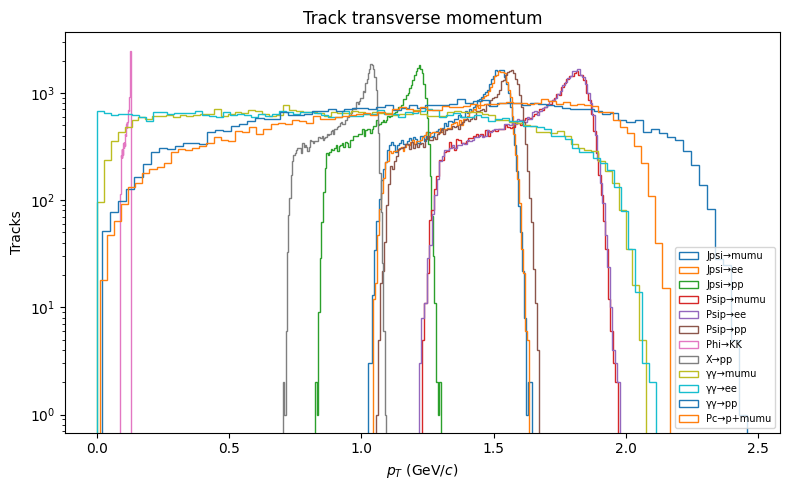

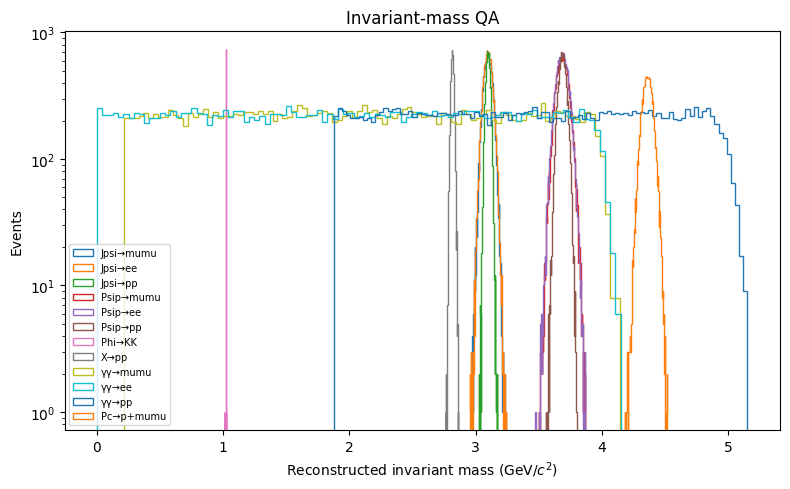

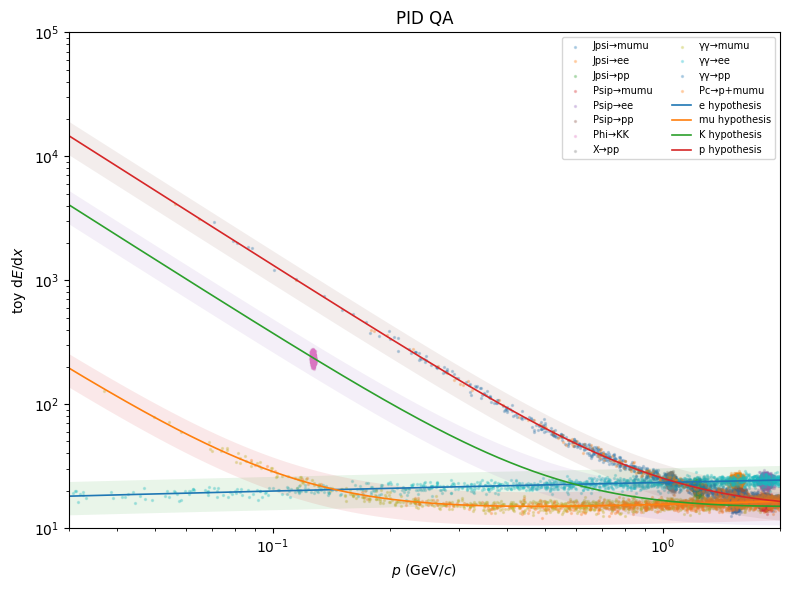

In [7]:
# Demo run. Increase n_per_process when you need larger training samples.
df = generate_all(n_per_process=30000, seed=127)
print(df["process"].value_counts())
print("Total events:", len(df))

df_acc = apply_acceptance(df, eta_max=0.9)
print("Events after |eta| < 0.9 for all final-state tracks:", len(df_acc))

QA(df_acc)


## What was fixed compared with the uploaded version

1. **Consistent labels**: the notebook now uses one pentaquark label everywhere: `Pc→p+mumu`.
2. **The final crash is fixed**: `first(df, exclude_processes=[...])` now works.
3. **3-body events are supported properly**: tables no longer assume every event has only two tracks.
4. **PID mapping is done track-by-track**: a `Pc→p+mumu` event has one proton and two muons, not three protons.
5. **Invariant mass is event-level and uses the true generated daughter masses**, rather than assigning the pion mass to every track.
6. **The demo uses a smaller default sample** so the notebook runs quickly; increase `n_per_process` for production studies.


In [8]:
# ------------------------------------------------------------------
# The two ML sets.  Both are track-level; `build_track_table` is run once and
# both sets are cut from it, so their rows line up index by index.
#
#   set 1 : InvariantMass, EventID, TrackID, N_sigma_e/mu/K/p
#   set 2 : mass_true,                       N_sigma_e/mu/K/p
# ------------------------------------------------------------------
tracks_all = build_track_table(df_acc)

set_one = first(df_acc, track_table=tracks_all)
set_two = second(df_acc, track_table=tracks_all)

# same two sets with the injected anomalies removed (training / reference)
ANOMALIES = ["Jpsi→pp", "Pc→p+mumu"]
tracks_clean = build_track_table(df_acc, exclude_processes=ANOMALIES)
set_one_clean = first(df_acc, track_table=tracks_clean)
set_two_clean = second(df_acc, track_table=tracks_clean)

print("set 1:", list(set_one.columns), set_one.shape, "| clean:", set_one_clean.shape)
print("set 2:", list(set_two.columns), set_two.shape, "| clean:", set_two_clean.shape)
display(set_one.head())
display(set_two.head())

# sanity checks
assert list(set_one.columns) == SET1_COLUMNS
assert list(set_two.columns) == SET2_COLUMNS
assert len(set_one) == len(set_two) == len(tracks_all)
assert set(set_one.EventID) <= set(df_acc.EventID)          # real IDs, not a counter
assert set_one.InvariantMass.std() > 0                      # not a constant column
assert set(set_two.mass_true) == {MASS["e"], MASS["mu"], MASS["K"], MASS["p"]}
# a 3-body Pc event keeps all three tracks, with two different true masses
pc_ids = df_acc.loc[df_acc.process == "Pc→p+mumu", "EventID"]
pc_tracks = tracks_all[tracks_all.EventID.isin(pc_ids)]
assert (pc_tracks.groupby("EventID").size() == 3).all()
assert pc_tracks.groupby("EventID").mass_true.nunique().eq(2).all()

set_one.to_csv("set1_tracks.csv", index=False)
set_two.to_csv("set2_masses.csv", index=False)
set_one_clean.to_csv("set1_tracks_without_anomalies.csv", index=False)
set_two_clean.to_csv("set2_masses_without_anomalies.csv", index=False)
print("true masses in set 2:")
display(set_two.mass_true.value_counts())

set 1: ['InvariantMass', 'EventID', 'TrackID', 'N_sigma_e', 'N_sigma_mu', 'N_sigma_K', 'N_sigma_p'] (514918, 7) | clean: (429540, 7)
set 2: ['mass_true', 'N_sigma_e', 'N_sigma_mu', 'N_sigma_K', 'N_sigma_p'] (514918, 5) | clean: (429540, 5)


,InvariantMass,EventID,TrackID,N_sigma_e,N_sigma_mu,N_sigma_K,N_sigma_p
0,3.084596,1,1,-5.744735,-0.361855,0.519927,-2.389182
1,3.084596,1,2,-6.464739,-1.439880,-0.587748,-3.255837
2,3.075432,2,1,-5.446293,0.081403,1.007799,-1.945412
3,3.075432,2,2,-5.294848,0.310762,1.219705,-1.824927
4,3.061298,4,1,-4.019822,2.215611,3.214369,-0.192263


,mass_true,N_sigma_e,N_sigma_mu,N_sigma_K,N_sigma_p
0,0.10566,-5.744735,-0.361855,0.519927,-2.389182
1,0.10566,-6.464739,-1.439880,-0.587748,-3.255837
2,0.10566,-5.446293,0.081403,1.007799,-1.945412
3,0.10566,-5.294848,0.310762,1.219705,-1.824927
4,0.10566,-4.019822,2.215611,3.214369,-0.192263


true masses in set 2:


mass_true
0.938270    185642
0.105660    157178
0.000511    129140
0.493670     42958
Name: count, dtype: int64

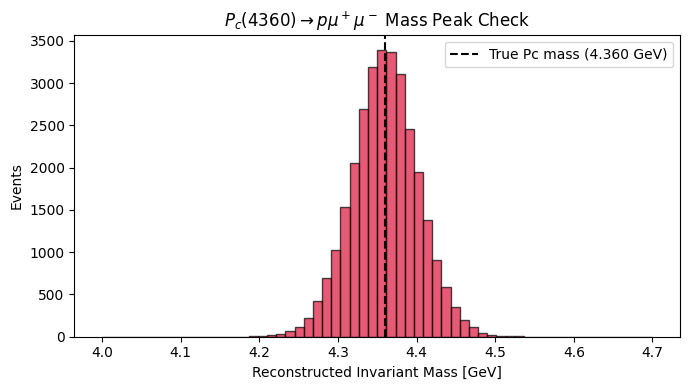

In [9]:
import matplotlib.pyplot as plt

# Filter and calculate reconstructed mass for Pc events
pc_df = df[df["process"] == "Pc→p+mumu"].copy()
m_pc = calculate_invariant_mass(pc_df)

plt.figure(figsize=(7, 4))
plt.hist(m_pc, bins=60, range=(4.0, 4.7), color="crimson", edgecolor="black", alpha=0.7)
plt.axvline(4.360, color="black", linestyle="--", label="True Pc mass (4.360 GeV)")
plt.xlabel("Reconstructed Invariant Mass [GeV]")
plt.ylabel("Events")
plt.title(r"$P_c(4360) \to p \mu^+ \mu^-$ Mass Peak Check")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
track_table = build_track_table(df_acc)
event_table = build_event_table(df_acc, track_table=track_table, nsigma_ref=0.5)

print("Track table")
display(track_table.head())
print("Event table")
display(event_table.head())

track_table.to_csv("track_based_table.csv", index=False)
event_table.to_csv("event_based_table.csv", index=False)


Track table


,EventID,TrackID,process,species,InvariantMass,mass_true,px,py,pz,p,pt,eta,E_true,dedx,N_sigma_e,N_sigma_mu,N_sigma_K,N_sigma_p
0,1,1,Jpsi→mumu,mu+,3.084596,0.10566,-1.246652,-0.012573,-0.889346,1.531416,1.246715,-0.663570,1.535056,15.732826,-5.744735,-0.361855,0.519927,-2.389182
1,1,2,Jpsi→mumu,mu-,3.084596,0.10566,1.258497,0.012692,0.897796,1.545967,1.258561,0.663570,1.549573,14.704357,-6.464739,-1.439880,-0.587748,-3.255837
2,2,1,Jpsi→mumu,mu+,3.075432,0.10566,1.399268,0.184360,-0.618418,1.540903,1.411361,-0.425239,1.544521,16.168962,-5.446293,0.081403,1.007799,-1.945412
3,2,2,Jpsi→mumu,mu-,3.075432,0.10566,-1.386907,-0.182731,0.612955,1.527290,1.398893,0.425239,1.530941,16.378119,-5.294848,0.310762,1.219705,-1.824927
4,4,1,Jpsi→mumu,mu+,3.061298,0.10566,-1.272222,-0.622290,-0.558578,1.522433,1.416260,-0.384834,1.526095,18.210832,-4.019822,2.215611,3.214369,-0.192263


Event table


,EventID,process,n_tracks,parent_mass,M_reco,N_tracks,N_e,N_mu,N_K,N_p
0,1,Jpsi→mumu,2,3.0969,3.084596,2,0,1,0,0
1,2,Jpsi→mumu,2,3.0969,3.075432,2,0,2,0,0
2,4,Jpsi→mumu,2,3.0969,3.061298,2,0,0,0,1
3,5,Jpsi→mumu,2,3.0969,3.106017,2,0,0,1,0
4,7,Jpsi→mumu,2,3.0969,3.066429,2,0,0,1,0
